# Testing the model

In [2]:
# Set the base dir to the project root
%cd ..
!pwd

/home/nathan/anaconda3/envs/pbi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code
/home/nathan/Documents/sync/HEIG_VD/TB-XAI/FoundedPBI-code


In [3]:
import torch
import pandas as pd
import os
from pbi_utils.data_manager import H5pyEmbeddingsManager, PerphectDataInput
from main import parse_config, reduce_dimensionality, test_model, make_dataset
import numpy as np
import matplotlib.pyplot as plt


In [4]:
config = parse_config(config_path="output/pbip/best/training_config.yaml")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 16384
[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 16384
[INFO] Configuration loaded from output/pbip/best/training_config.yaml: Config(input_perphect=bacteria_df='data/perphect-data/predphi/bacteria_sequences.csv' phages_df='data/perphect-data/predphi/bacteriophages_sequences.csv' couples_df='data/perphect-data/predphi/predphi_train_dataset.csv', embeddings_dir=data/embeddings-pbip, num_gpu=0, gpu_id=0, training_config=TrainingConfig(do_train=True do_test=True epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 training_noise_std=0.05 stratify_cv=True k_folds_cv=10 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_lr=1000 monitor_metric_reduce_lr='f1' multiplying_factor_reduce_lr=0.5 reduce_dimensionality='none' n_components_bacteria=None n_components_phages=None), phages_embedding_models=[NT2(merging_strategy=TopBottomTruncateStrategy(), overlap=0, model_name='nucleotide-transform

### Load dataset

In [5]:
# Hardcode test dataset path. Only used for the PredPHI data, on the CI4CB data, ignore this cell.
config.input_perphect.couples_df = "data/perphect-data/predphi/predphi_test_dataset.csv"

In [6]:
# Assumming that all the embeddings have already been computed
output_manager = H5pyEmbeddingsManager(config.embeddings_dir)

[INFO] Embeddings will be stored or read from data/embeddings-pbip


In [7]:
bacteria_df, phages_df, couples_df = PerphectDataInput(input_paths=config.input_perphect).load()

[INFO] Perphect input files will be read from data/perphect-data/predphi/bacteria_sequences.csv, data/perphect-data/predphi/bacteriophages_sequences.csv and data/perphect-data/predphi/predphi_test_dataset.csv
[INFO] Reading csv files...


In [8]:
bacteria_model_names = [x.name() for x in config.bacteria_embedding_models]
phages_model_names = [x.name() for x in config.phages_embedding_models]
dataset = make_dataset(couples_df, bacteria_model_names, phages_model_names, output_manager, device)
dataset = reduce_dimensionality(dataset, config.training_config.reduce_dimensionality, config.output_dir, config.training_config.n_components_bacteria, config.training_config.n_components_phages)


[INFO] Creating dataset (loading embeddings)...
[DEBUG] Loading 1236 embeddings for model NT2-TruncateStrategy-250M-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/1236 [00:00<?, ?it/s]

[DEBUG] Loading 1236 embeddings for model MegaDNA-TruncateStrategy-concat-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/1236 [00:00<?, ?it/s]

[DEBUG] Loading 1236 embeddings for model DNABERT2-BottomTruncateStrategy-ov0-maxlen16384 from data/embeddings-pbip


...

[DEBUG] Loading 1236 embeddings for model MegaDNA-TopBottomTruncateStrategy-concat-ov0 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/1236 [00:00<?, ?it/s]

[DEBUG] Loading 1236 embeddings for model DNABERT2-TKPert-concat-J16-g20-ov0-maxlen16384 from data/embeddings-pbip


Loading embeddings:   0%|          | 0/1236 [00:00<?, ?it/s]

[DEBUG] Final embedding size (bacteria): 2500
[DEBUG] Final embedding size (phages): 15752


In [9]:
dataset.head()

,phage_id,bacterium_id,interaction_type,bacterium_embedding,phage_embedding
0,NC_019400,CALF01000071,1,"[tensor(0.0652, device='cuda:0'), tensor(0.015...","[tensor(0.1758, device='cuda:0'), tensor(0.233..."
1,MF919516,CP012196,0,"[tensor(-0.0643, device='cuda:0'), tensor(-0.0...","[tensor(0.3073, device='cuda:0'), tensor(0.416..."
2,NC_019813,CP011132,0,"[tensor(0.0619, device='cuda:0'), tensor(0.162...","[tensor(0.0379, device='cuda:0'), tensor(0.155..."
3,NC_027355,CM000736,1,"[tensor(-0.0317, device='cuda:0'), tensor(-0.2...","[tensor(0.0881, device='cuda:0'), tensor(-0.12..."
4,NC_021790,CP009976,1,"[tensor(-0.1541, device='cuda:0'), tensor(-0.6...","[tensor(0.0610, device='cuda:0'), tensor(0.036..."


### Load the model
Make sure to use the same architecture and parameters that were used for training it. See the yaml file that was used.

In [10]:
model_path = os.path.join(config.output_dir, "trained_model.pth")

In [11]:
bacterium_embed_size = len(dataset["bacterium_embedding"].iloc[0])
phage_embed_size = len(dataset["phage_embedding"].iloc[0])
model = config.classifier(bacterium_embed_size, phage_embed_size, **config.classifier_params)

model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)

### Test the model

In [12]:
test_model(dataset, model, batch_size=config.training_config.batch_size, device=device);

[INFO] Starting testing...
[INFO] Accuracy (test): 0.7508090734481812
[INFO] Recall (test): 0.7750809192657471
[INFO] F1 score (test): 0.7567140460014343
[INFO] Loss (test): 0.7344119267170484
[INFO] Confusion Matrix (test) (TP, FP, FN, TN): (479, 169, 139, 449)


### Do 1 prediction

In [13]:
# Do 1 prediction example
example = dataset.iloc[0]
bacterium_embedding = example["bacterium_embedding"].clone().detach().unsqueeze(0).to(device)
phage_embedding = example["phage_embedding"].clone().detach().unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    output = model(bacterium_embedding, phage_embedding)
    probs = torch.sigmoid(output).squeeze().cpu().numpy()
    print(f"Predicted interaction probability for bacterium {example['bacterium_id']} and phage {example['phage_id']}: Label {np.argmax(probs)} with probability {np.max(probs):.6f}. True label: {example['interaction_type']}")

Predicted interaction probability for bacterium CALF01000071 and phage NC_019400: Label 0 with probability 0.750215. True label: 1


### View missed predictions

In [14]:
dataset[['prediction', 'probability']] = dataset.apply(
    lambda row: pd.Series({
        'prediction': int(torch.argmax(model(
            row['bacterium_embedding'].unsqueeze(0).to(device),
            row['phage_embedding'].unsqueeze(0).to(device)
        )).squeeze().detach().cpu().numpy()),
        'probability': float(torch.softmax(model(  # proba d'interaction (classe 1)
            row['bacterium_embedding'].unsqueeze(0).to(device),
            row['phage_embedding'].unsqueeze(0).to(device)
        ), dim=1)[0, 1].detach().cpu().numpy())
    }), axis=1
)
dataset.head()


,phage_id,bacterium_id,interaction_type,bacterium_embedding,phage_embedding,prediction,probability
0,NC_019400,CALF01000071,1,"[tensor(0.0652, device='cuda:0'), tensor(0.015...","[tensor(0.1758, device='cuda:0'), tensor(0.233...",0.0,0.111976
1,MF919516,CP012196,0,"[tensor(-0.0643, device='cuda:0'), tensor(-0.0...","[tensor(0.3073, device='cuda:0'), tensor(0.416...",0.0,0.127122
2,NC_019813,CP011132,0,"[tensor(0.0619, device='cuda:0'), tensor(0.162...","[tensor(0.0379, device='cuda:0'), tensor(0.155...",0.0,0.156426
3,NC_027355,CM000736,1,"[tensor(-0.0317, device='cuda:0'), tensor(-0.2...","[tensor(0.0881, device='cuda:0'), tensor(-0.12...",0.0,0.079894
4,NC_021790,CP009976,1,"[tensor(-0.1541, device='cuda:0'), tensor(-0.6...","[tensor(0.0610, device='cuda:0'), tensor(0.036...",1.0,0.972886


In [15]:
print(dataset.groupby('interaction_type')['probability'].describe())


                  count      mean       std           min       25%       50%  \
interaction_type                                                                
0                 618.0  0.272351  0.376301  1.833493e-17  0.000063  0.023252   
1                 618.0  0.731262  0.325284  4.273067e-06  0.566396  0.904630   

                       75%       max  
interaction_type                      
0                 0.577271  0.999563  
1                 0.981504  0.999902  


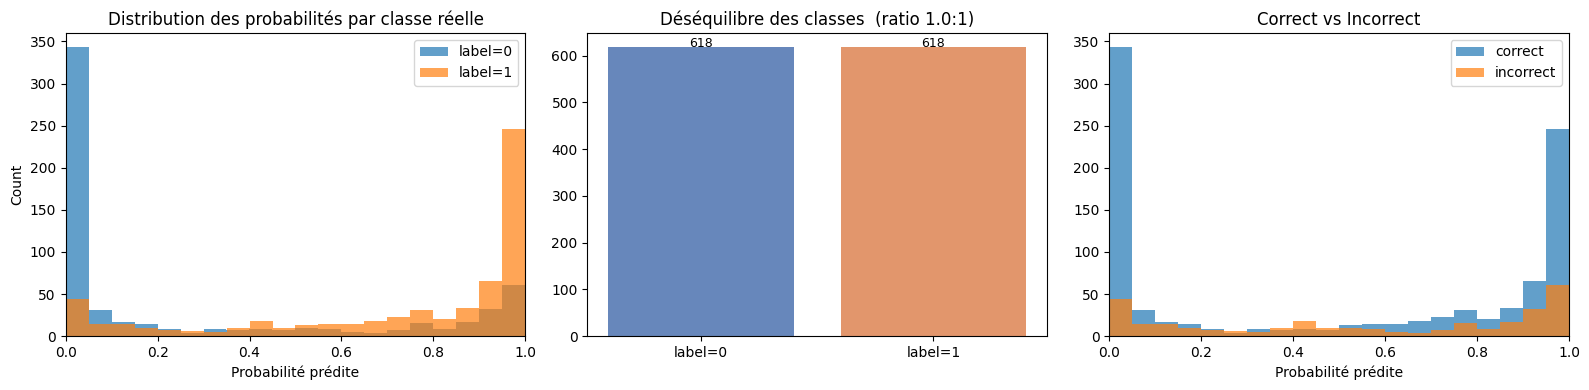

In [43]:
# ── Distribution globale des sorties ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for label, grp in dataset.groupby('interaction_type'):
    axes[0].hist(grp['probability'], bins=20, alpha=0.7, label=f'label={int(label)}')
axes[0].set_xlabel('Probabilité prédite'); axes[0].set_ylabel('Count')
axes[0].set_title('Distribution des probabilités par classe réelle'); axes[0].legend()
axes[0].set_xlim(0, 1)

counts = dataset['interaction_type'].value_counts().sort_index()
axes[1].bar([f'label={int(i)}' for i in counts.index], counts.values,
            color=['#4C72B0', '#DD8452'], alpha=0.85)
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=9)
axes[1].set_title(f'Déséquilibre des classes  (ratio {counts.max()/counts.min():.1f}:1)')

correct = dataset['prediction'] == dataset['interaction_type']
axes[2].hist(dataset[correct]['probability'],  bins=20, alpha=0.7, label='correct')
axes[2].hist(dataset[~correct]['probability'], bins=20, alpha=0.7, label='incorrect')
axes[2].set_xlabel('Probabilité prédite'); axes[2].set_title('Correct vs Incorrect'); axes[2].legend()
axes[2].set_xlim(0, 1)
plt.tight_layout(); plt.show()


In [44]:
def entity_summary(dataset, id_col):
    rows = []
    for entity_id, grp in dataset.groupby(id_col):
        n_pos   = int((grp['interaction_type'] == 1).sum())
        n_neg   = int((grp['interaction_type'] == 0).sum())
        n_total = n_pos + n_neg
        mse     = ((grp['probability'] - grp['interaction_type']) ** 2).mean()
        bias    = (grp['probability'] - grp['interaction_type']).mean()
        acc     = (grp['prediction'] == grp['interaction_type']).mean()
        mean_pred = grp['probability'].mean()
        rows.append({
            id_col:      entity_id,
            'n_pos':     n_pos,
            'n_neg':     n_neg,
            'n_total':   n_total,
            'ratio_pos': n_pos / n_total,
            'mean_pred': mean_pred,
            'mse':       mse,
            'bias':      bias,
            'accuracy':  acc,
        })
    return pd.DataFrame(rows).set_index(id_col).sort_values('mse', ascending=False)

bact_summary  = entity_summary(dataset, 'bacterium_id')
phage_summary = entity_summary(dataset, 'phage_id')

print('=== Bactéries (triées par MSE, n_total >= 10) ===')
print(bact_summary[bact_summary['n_total'] >= 10].to_string(float_format='{:.3f}'.format))
print()
print('=== Phages (triés par MSE, n_total >= 4) ===')
print(phage_summary[phage_summary['n_total'] >= 4].to_string(float_format='{:.3f}'.format))


=== Bactéries (triées par MSE, n_total >= 10) ===
              n_pos  n_neg  n_total  ratio_pos  mean_pred   mse   bias  accuracy
bacterium_id                                                                    
HG530068         97      4      101      0.960      0.492 0.456 -0.468     0.475
CP000628          2      9       11      0.182      0.682 0.433  0.500     0.455
CP000113          1      9       10      0.100      0.499 0.365  0.399     0.600
CP005976          4      7       11      0.364      0.199 0.332 -0.165     0.636
CP000554         21      2       23      0.913      0.540 0.314 -0.373     0.565
CP010812         26      2       28      0.929      0.477 0.303 -0.452     0.571
CP001932          1     10       11      0.091      0.314 0.299  0.224     0.545
CP009257         22      5       27      0.815      0.596 0.296 -0.219     0.556
CP014326          1      9       10      0.100      0.425 0.287  0.325     0.600
CP001312          4      7       11      0.364      0.614 0

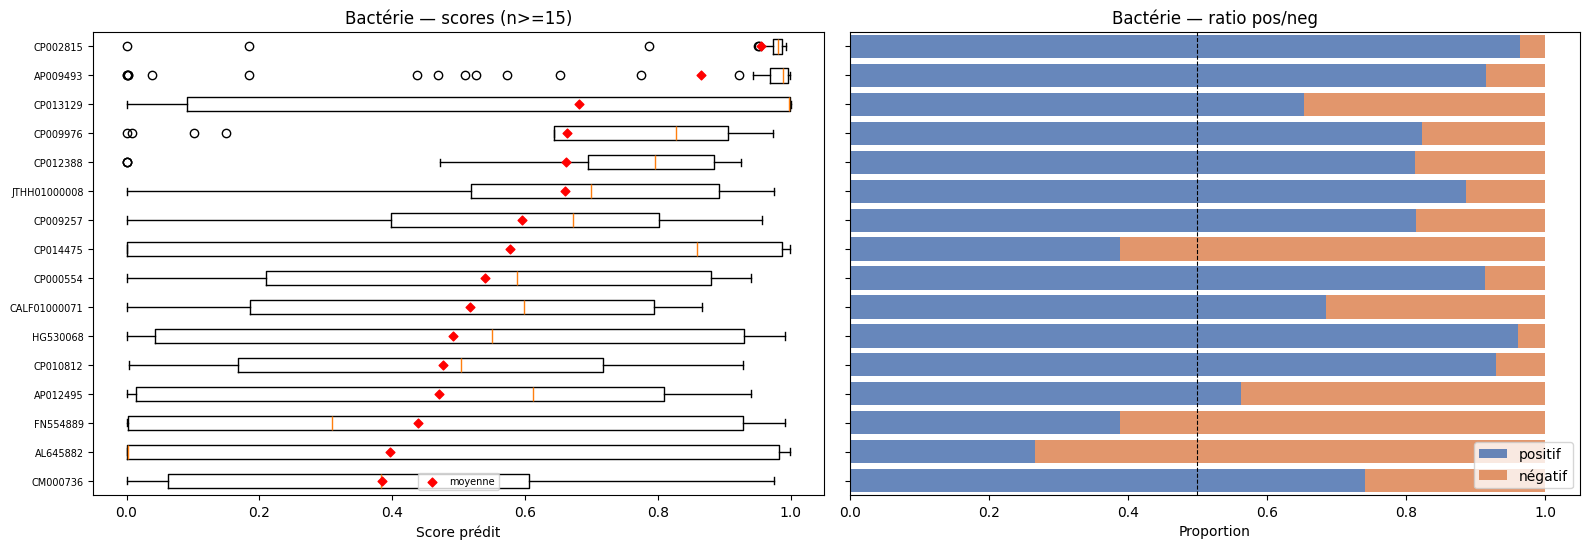

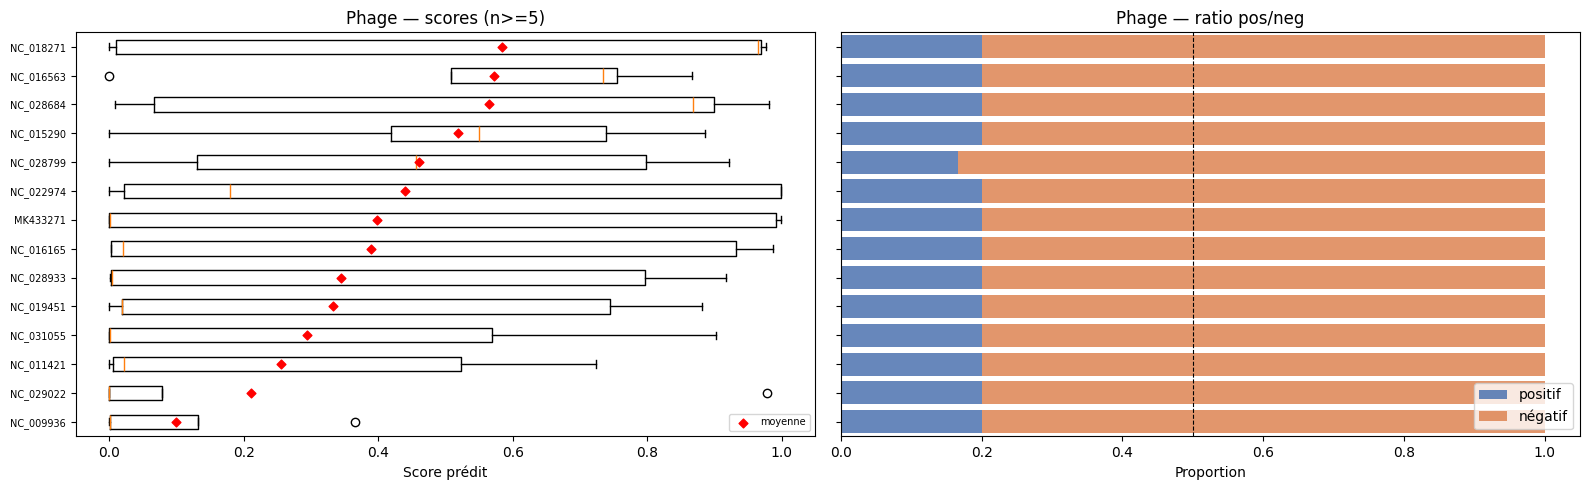

In [49]:
def plot_entity_distribution(summary, dataset, id_col, min_total, title):
    sub = summary[summary['n_total'] >= min_total].sort_values('mean_pred')
    order = sub.index

    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(order) * 0.35)), sharey=True)

    # Boxplot horizontal + moyenne (depuis dataset brut)
    data  = [dataset[dataset[id_col] == e]['probability'].values for e in order]
    means = sub['mean_pred'].values
    axes[0].boxplot(data, positions=range(len(order)), vert=False)
    axes[0].scatter(means, range(len(order)), marker='D', color='red',
                    zorder=3, s=20, label='moyenne')
    axes[0].set_xlabel('Score prédit'); axes[0].set_title(f'{title} — scores (n>={min_total})')
    axes[0].tick_params(axis='y', labelsize=7); axes[0].legend(fontsize=7)

    # Stacked bar ratio pos/neg (depuis summary)
    y = range(len(order))
    axes[1].barh(y, sub['ratio_pos'],                 alpha=0.85, color='#4C72B0', label='positif')
    axes[1].barh(y, 1 - sub['ratio_pos'], left=sub['ratio_pos'], alpha=0.85, color='#DD8452', label='négatif')
    axes[1].set_yticks(y); axes[1].set_yticklabels(order, fontsize=7)
    axes[1].set_xlabel('Proportion'); axes[1].set_title(f'{title} — ratio pos/neg')
    axes[1].legend(loc='lower right')
    axes[1].axvline(0.5, color='black', linewidth=0.8, linestyle='--')

    plt.tight_layout(); plt.show()

plot_entity_distribution(bact_summary,  dataset, 'bacterium_id', 15, 'Bactérie')
plot_entity_distribution(phage_summary, dataset, 'phage_id',      5, 'Phage')


In [40]:
cp_samples = dataset[dataset['bacterium_id'] == 'CP013129']
print(cp_samples[['phage_id', 'interaction_type','prediction', 'probability']].to_string())


       phage_id  interaction_type  prediction   probability
21    NC_018849                 0         0.0  6.139986e-03
22    NC_005345                 1         1.0  9.991038e-01
34     KT184391                 1         1.0  9.984484e-01
141    KT895281                 0         0.0  2.463869e-04
277    KT186228                 1         1.0  9.986824e-01
279   NC_028827                 1         1.0  9.984301e-01
350   NC_018848                 1         1.0  9.999019e-01
358    MK305888                 1         1.0  9.984698e-01
386    MF541406                 1         1.0  9.856354e-01
410    KY092482                 1         1.0  9.996865e-01
541    KX507344                 1         1.0  9.915355e-01
646    KU958700                 1         1.0  9.988426e-01
660    KT124228                 1         1.0  9.909400e-01
716   NC_023566                 0         0.0  1.656398e-06
773   NC_001396                 0         0.0  1.987023e-04
785    KT186229                 1       

### XAI — Gradient-based embedding importance

Pour chaque sample, on calcule le gradient de la sortie du modèle par rapport aux embeddings d'entrée.  
Un gradient élevé sur une dimension = le modèle y est très sensible = elle influence fortement la prédiction.

**Étapes :**
1. Récupérer la taille de chaque modèle individuel (NT2, MegaDNA, DNABERT2) pour savoir où couper le vecteur concaténé
2. Faire un `backward()` pour chaque sample → gradients w.r.t. les embeddings
3. Agréger `mean(|gradient|)` sur tous les samples → importance moyenne par dimension
4. Visualiser par modèle (bactérie / phage)

In [18]:
# Étape 1 : récupérer la taille de chaque modèle individuellement
sample_bact_id  = dataset['bacterium_id'].iloc[0]
sample_phage_id = dataset['phage_id'].iloc[0]


def to_display_name(full_name):
    strategies = {
        'TopBottomTruncateStrategy': 'TopBottom',
        'BottomTruncateStrategy':    'Bottom',
        'TruncateStrategy':          'Trunc',
        'TKPert':                    'TKPert',
    }
    base = full_name.split('-')[0]
    for key, short in strategies.items():
        if key in full_name:
            return base + ' (' + short + ')'
    return base


def build_model_info(model_names, sample_id, output_manager, device, side):
    info  = {}
    start = 0
    for name in model_names:
        emb  = output_manager.load_embedding_batch([sample_id], model_name=name, silent=True, device=device)
        size = len(emb[0])
        info[name] = {
            'display': to_display_name(name),
            'slice':   slice(start, start + size),
            'size':    size,
            'side':    side,
        }
        start += size
    return info

def _col(info):
    return 'bacterium_embedding' if info['side'] == 'bact' else 'phage_embedding'


bact_info  = build_model_info(bacteria_model_names, sample_bact_id,  output_manager, device, 'bact')
phage_info = build_model_info(phages_model_names,   sample_phage_id, output_manager, device, 'phage')

for info_dict in [bact_info, phage_info]:
    side = next(iter(info_dict.values()))['side']
    print(f'{side}:')
    for info in info_dict.values():
        print(f"  {info['display']}: {info['size']} dims")
    print(f"  Total: {sum(v['size'] for v in info_dict.values())}")


[DEBUG] Loading 1 embeddings for model NT2-TruncateStrategy-250M-ov0 from data/embeddings-pbip
[DEBUG] Loading 1 embeddings for model MegaDNA-TruncateStrategy-concat-ov0 from data/embeddings-pbip
[DEBUG] Loading 1 embeddings for model DNABERT2-BottomTruncateStrategy-ov0-maxlen16384 from data/embeddings-pbip
[DEBUG] Loading 1 embeddings for model NT2-TopBottomTruncateStrategy-250M-ov0 from data/embeddings-pbip
[DEBUG] Loading 1 embeddings for model MegaDNA-TopBottomTruncateStrategy-concat-ov0 from data/embeddings-pbip
[DEBUG] Loading 1 embeddings for model DNABERT2-TKPert-concat-J16-g20-ov0-maxlen16384 from data/embeddings-pbip
bact:
  NT2 (Trunc): 768 dims
  MegaDNA (Trunc): 964 dims
  DNABERT2 (Bottom): 768 dims
  Total: 2500
phage:
  NT2 (TopBottom): 1536 dims
  MegaDNA (TopBottom): 1928 dims
  DNABERT2 (TKPert): 12288 dims
  Total: 15752


In [19]:
# Sous-infos top / bottom pour les modèles TopBottomTruncateStrategy
def _sub_info(info, part):
    """Extrait top (1ère moitié) ou bottom (2ème moitié) d'un modèle TopBottom."""
    sl, half = info['slice'], info['size'] // 2
    base = info['display'].replace(' (TopBottom)', '')

    if part == 'top':
        return {'side': info['side'], 'slice': slice(sl.start,        sl.start + half), 'size': half, 'display' : base + ' (Top splited)',}
    else:
        return {'side': info['side'], 'slice': slice(sl.start + half, sl.stop), 'size': info['size'] - half, 'display' : base + ' (Bottom splited)',}


topbottom_info = {}
for info_dict in [bact_info, phage_info]:
    for name, info in info_dict.items():
        if 'TopBottom' not in info['display']:
            continue
        base = info['display'].replace(' (TopBottom)', '')
        sl, half = info['slice'], info['size'] // 2
        topbottom_info[name + '_top'] = _sub_info(info, 'top')
        topbottom_info[name + '_bottom'] = _sub_info(info, 'bottom')

for info in topbottom_info.values():
    print(f"  {info['display']} ({info['side']}): {info['size']} dims")


  NT2 (Top splited) (phage): 768 dims
  NT2 (Bottom splited) (phage): 768 dims
  MegaDNA (Top splited) (phage): 964 dims
  MegaDNA (Bottom splited) (phage): 964 dims


In [20]:
# Étape 2 : calculer les gradients pour chaque sample
# On backpropage depuis la probabilité de la CLASSE 1 (interaction = vrai)
# car le modèle retourne 2 logits → shape (1, 2) → on prend output[:, 1]
model.eval()

all_grad_bact = []
all_grad_phage = []

for _, row in dataset.iterrows():
    bact_emb = row["bacterium_embedding"].clone().float().to(device).unsqueeze(0).requires_grad_(True)
    phage_emb = row["phage_embedding"].clone().float().to(device).unsqueeze(0).requires_grad_(True)

    output = model(bact_emb, phage_emb)          # shape (1, 2)
    prob = torch.sigmoid(output[:, 1]).squeeze()  # probabilité classe 1, scalaire
    prob.backward()

    all_grad_bact.append(bact_emb.grad.squeeze().abs().detach().cpu().numpy())
    all_grad_phage.append(phage_emb.grad.squeeze().abs().detach().cpu().numpy())

mean_grad_bact = np.mean(all_grad_bact, axis=0)
mean_grad_phage = np.mean(all_grad_phage, axis=0)

print(f"Gradients calculés sur {len(all_grad_bact)} samples.")


Gradients calculés sur 1236 samples.


In [21]:
def store_by_model(mean_grad, model_info, key):
    """Stocke découpé par modèle directement dans model_info[name][key]."""
    for info in model_info.values():
        info[key] = mean_grad[info['slice']]


store_by_model(mean_grad_bact,  bact_info,  'grad_importance')
store_by_model(mean_grad_phage, phage_info, 'grad_importance')

print('Importance par modèle (sum |gradient|):')
print('Bactérie:')
for name, info in bact_info.items():
    g = info['grad_importance']
    print('  ' + info['display'] + ': sum=' + f'{g.sum():.4f}  mean={g.mean():.6f}  dims={len(g)}')
print('Phage:')
for name, info in phage_info.items():
    g = info['grad_importance']
    print('  ' + info['display'] + ': sum=' + f'{g.sum():.4f}  mean={g.mean():.6f}  dims={len(g)}')


Importance par modèle (sum |gradient|):
Bactérie:
  NT2 (Trunc): sum=4.0825  mean=0.005316  dims=768
  MegaDNA (Trunc): sum=4.8301  mean=0.005010  dims=964
  DNABERT2 (Bottom): sum=3.5130  mean=0.004574  dims=768
Phage:
  NT2 (TopBottom): sum=8.9175  mean=0.005806  dims=1536
  MegaDNA (TopBottom): sum=9.7183  mean=0.005041  dims=1928
  DNABERT2 (TKPert): sum=38.3948  mean=0.003125  dims=12288


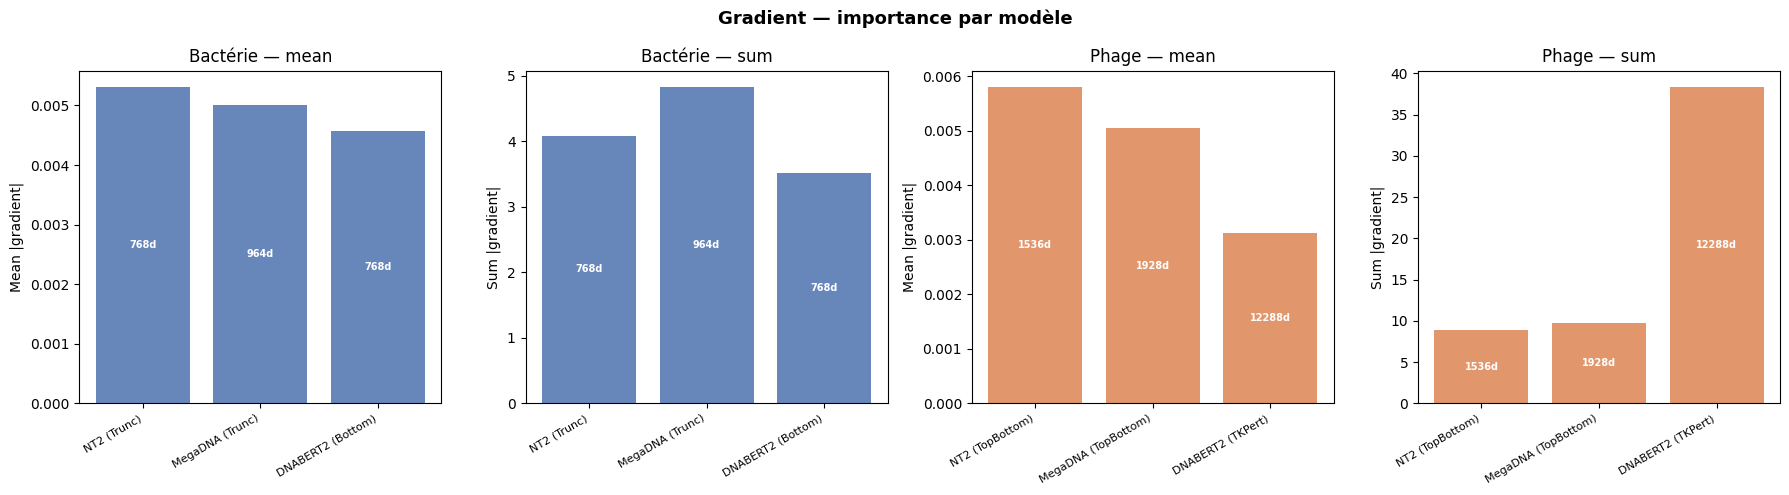

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.subplots_adjust(bottom=0.25)

for ax, info_dict, attr, side, color, ylabel in [
    (axes[0], bact_info,  'mean', 'Bactérie', '#4C72B0', 'Mean |gradient|'),
    (axes[1], bact_info,  'sum',  'Bactérie', '#4C72B0', 'Sum |gradient|'),
    (axes[2], phage_info, 'mean', 'Phage',    '#DD8452', 'Mean |gradient|'),
    (axes[3], phage_info, 'sum',  'Phage',    '#DD8452', 'Sum |gradient|'),
]:
    labels = [info['display'] for info in info_dict.values()]
    vals   = [getattr(info['grad_importance'], attr)() for info in info_dict.values()]
    bars   = ax.bar(range(len(vals)), vals, color=color, alpha=0.85)
    ax.set_xticks(range(len(vals))); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'{side} — {attr}')
    ax.set_ylabel(ylabel)
    for bar, val, info in zip(bars, vals, info_dict.values()):
        ax.text(bar.get_x() + bar.get_width()/2, val * 0.5, str(info['size']) + 'd',
                ha='center', va='center', fontsize=7, color='white', fontweight='bold')

plt.suptitle('Gradient — importance par modèle', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


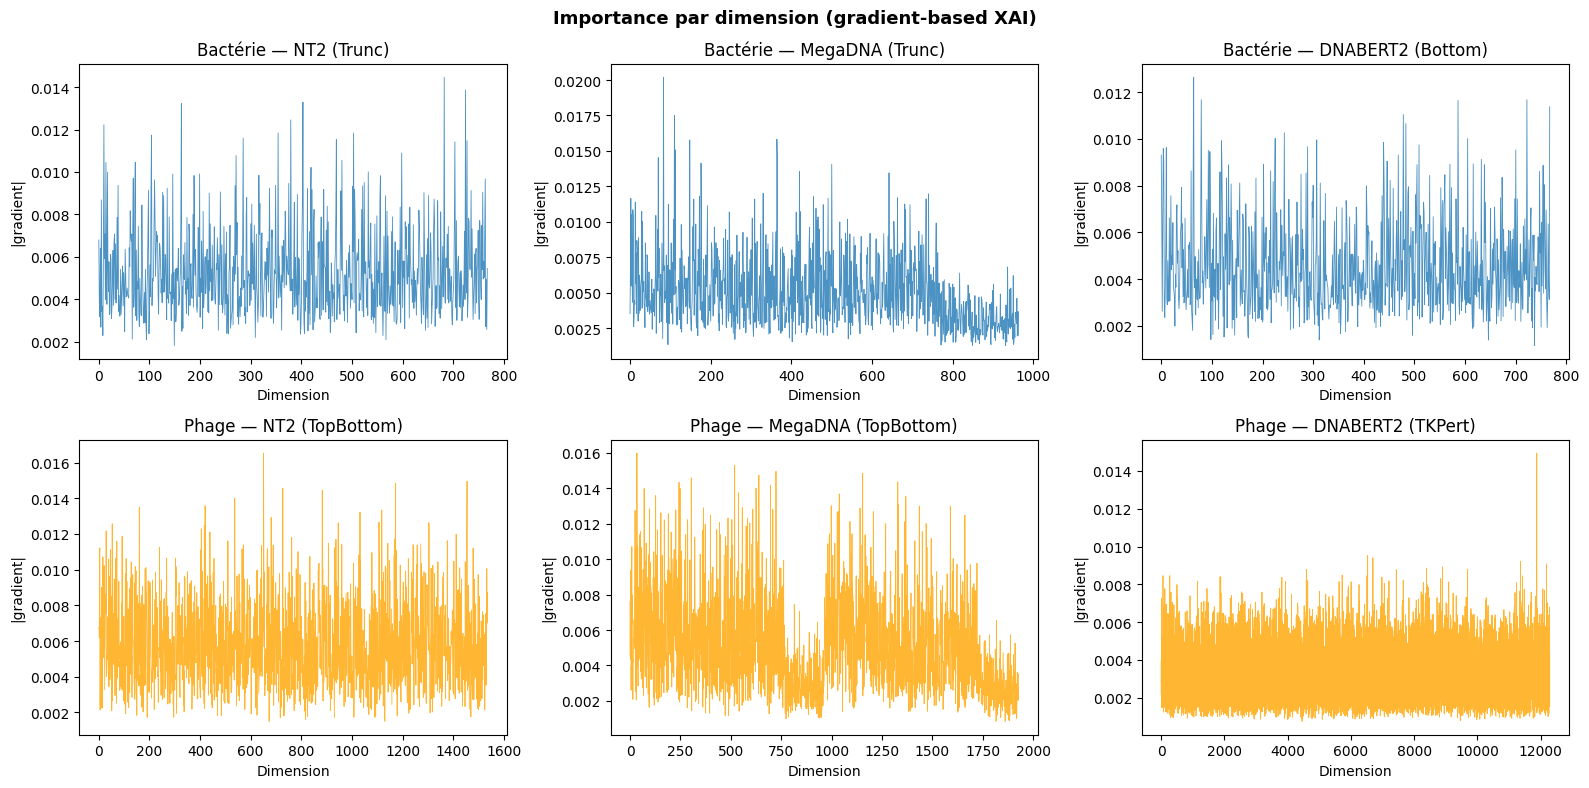

In [23]:
fig, axes = plt.subplots(2, len(bact_info), figsize=(16, 8))

for col, info in enumerate(bact_info.values()):
    axes[0][col].plot(info['grad_importance'], linewidth=0.6, alpha=0.8)
    axes[0][col].set_title('Bactérie — ' + info['display'])
    axes[0][col].set_xlabel('Dimension'); axes[0][col].set_ylabel('|gradient|')

for col, info in enumerate(phage_info.values()):
    axes[1][col].plot(info['grad_importance'], linewidth=0.6, alpha=0.8, color='orange')
    axes[1][col].set_title('Phage — ' + info['display'])
    axes[1][col].set_xlabel('Dimension'); axes[1][col].set_ylabel('|gradient|')

plt.suptitle('Importance par dimension (gradient-based XAI)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### XAI — Integrated Gradients (IG)

Contrairement au gradient simple (calculé au point x), IG intègre les gradients sur tout le chemin depuis une **baseline** (embedding nul) jusqu'à x :

```
IG(x) = (x - 0) * mean(gradients sur 50 interpolations de 0 → x)
```

Propriété **completeness** : `sum(IG_bact) + sum(IG_phage) ≈ prob(x) - prob(baseline)` — vérifiable et garanti.

In [24]:
def integrated_gradients(model, bact_emb, phage_emb, n_steps=50):
    """
    Calcule les Integrated Gradients pour une paire (bactérie, phage).
    baseline = vecteur nul (absence de signal).
    Retourne ig_bact et ig_phage : contribution signée de chaque dimension.
    """
    baseline_bact  = torch.zeros_like(bact_emb)
    baseline_phage = torch.zeros_like(phage_emb)
    alphas = torch.linspace(0, 1, n_steps).to(device)

    grads_bact  = []
    grads_phage = []

    for alpha in alphas:
        interp_bact  = (baseline_bact  + alpha * (bact_emb  - baseline_bact)).detach().requires_grad_(True)
        interp_phage = (baseline_phage + alpha * (phage_emb - baseline_phage)).detach().requires_grad_(True)

        output = model(interp_bact, interp_phage)
        prob   = torch.sigmoid(output[:, 1]).squeeze()
        prob.backward()

        grads_bact.append(interp_bact.grad.squeeze().detach())
        grads_phage.append(interp_phage.grad.squeeze().detach())

    avg_grads_bact  = torch.stack(grads_bact).mean(dim=0)
    avg_grads_phage = torch.stack(grads_phage).mean(dim=0)

    ig_bact  = (bact_emb.squeeze()  - baseline_bact.squeeze())  * avg_grads_bact
    ig_phage = (phage_emb.squeeze() - baseline_phage.squeeze()) * avg_grads_phage

    return ig_bact, ig_phage


# Vérification completeness sur 1 sample
model.eval()
row0 = dataset.iloc[0]
b0 = row0['bacterium_embedding'].clone().float().to(device).unsqueeze(0)
p0 = row0['phage_embedding'].clone().float().to(device).unsqueeze(0)

ig_b0, ig_p0 = integrated_gradients(model, b0, p0)

with torch.no_grad():
    prob_x        = torch.sigmoid(model(b0, p0)[:, 1]).item()
    prob_baseline = torch.sigmoid(model(torch.zeros_like(b0), torch.zeros_like(p0))[:, 1]).item()

ig_sum = ig_b0.sum().item() + ig_p0.sum().item()
delta  = prob_x - prob_baseline
print(f'Sum(IG)            : {ig_sum:.4f}')
print(f'prob(x)-prob(base) : {delta:.4f}')
print(f'Erreur completeness: {abs(ig_sum - delta):.6f}  (doit etre proche de 0)')


Sum(IG)            : -0.5004
prob(x)-prob(base) : -0.5040
Erreur completeness: 0.003610  (doit etre proche de 0)


In [25]:
# Calcul des IG sur tout le dataset + seulement predictions correctes
N_STEPS = 50
all_ig_bact,      all_ig_phage      = [], []

model.eval()
for _, row in dataset.iterrows():
    bact_emb  = row['bacterium_embedding'].clone().float().to(device).unsqueeze(0)
    phage_emb = row['phage_embedding'].clone().float().to(device).unsqueeze(0)

    ig_bact, ig_phage = integrated_gradients(model, bact_emb, phage_emb, n_steps=N_STEPS)

    all_ig_bact.append(ig_bact.abs().cpu().numpy())
    all_ig_phage.append(ig_phage.abs().cpu().numpy())


mean_ig_bact          = np.mean(all_ig_bact,     axis=0)
mean_ig_phage         = np.mean(all_ig_phage,    axis=0)

print('IG calculés sur ' + str(len(all_ig_bact)) + ' samples.')


IG calculés sur 1236 samples.


In [26]:
store_by_model(mean_ig_bact,  bact_info,  'ig_importance')
store_by_model(mean_ig_phage, phage_info, 'ig_importance')


Samples confiants (p >= 0.8): 483 / 1236
  dont corrects   : 365
  dont incorrects : 118


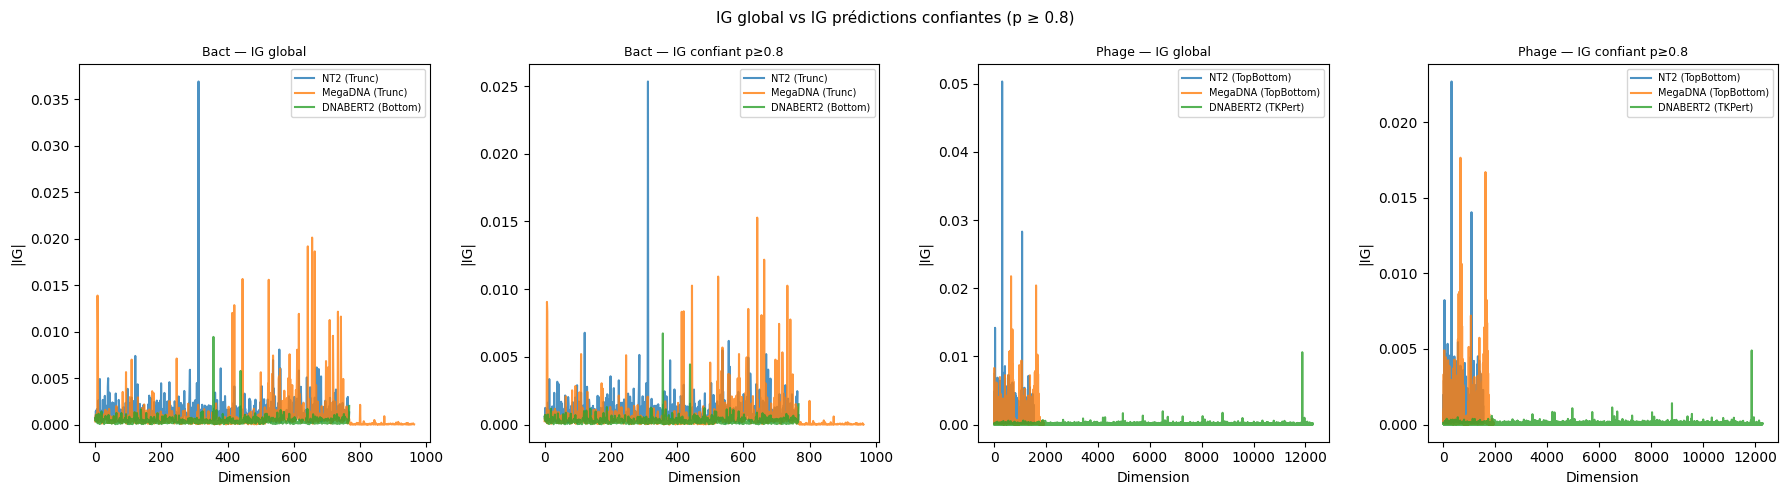

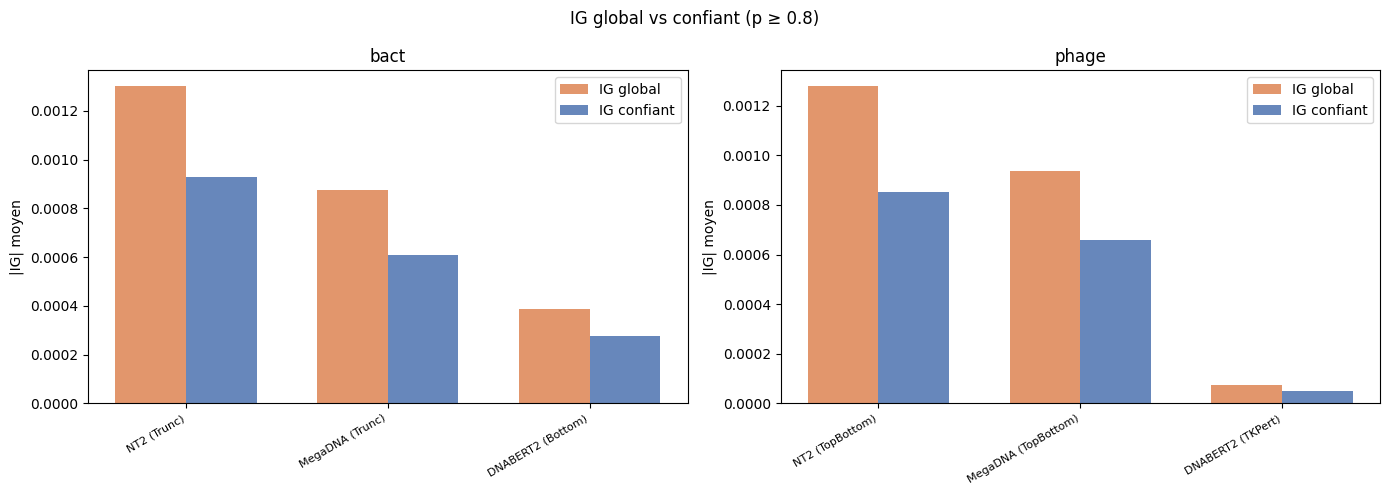

In [27]:
# IG sur les prédictions confiantes uniquement (réutilise all_ig_bact/phage)
CONFIDENCE_THRESHOLD = 0.8

conf_mask = dataset['probability'].values >= CONFIDENCE_THRESHOLD
print(f'Samples confiants (p >= {CONFIDENCE_THRESHOLD}): {conf_mask.sum()} / {len(dataset)}')
print(f'  dont corrects   : {(dataset[conf_mask]["prediction"] == dataset[conf_mask]["interaction_type"]).sum()}')
print(f'  dont incorrects : {(dataset[conf_mask]["prediction"] != dataset[conf_mask]["interaction_type"]).sum()}')

mean_ig_bact_conf  = np.mean([ig for ig, m in zip(all_ig_bact,  conf_mask) if m], axis=0)
mean_ig_phage_conf = np.mean([ig for ig, m in zip(all_ig_phage, conf_mask) if m], axis=0)

store_by_model(mean_ig_bact_conf,  bact_info,  'ig_importance_conf')
store_by_model(mean_ig_phage_conf, phage_info, 'ig_importance_conf')

# ── Comparaison IG global vs IG confiant ─────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.subplots_adjust(bottom=0.25)
for ax, info_dict, attr, title in [
    (axes[0], bact_info,  'ig_importance',      'Bact — IG global'),
    (axes[1], bact_info,  'ig_importance_conf',  f'Bact — IG confiant p≥{CONFIDENCE_THRESHOLD}'),
    (axes[2], phage_info, 'ig_importance',      'Phage — IG global'),
    (axes[3], phage_info, 'ig_importance_conf',  f'Phage — IG confiant p≥{CONFIDENCE_THRESHOLD}'),
]:
    for info in info_dict.values():
        ax.plot(info[attr], label=info['display'], alpha=0.8)
    ax.set_title(title, fontsize=9); ax.set_xlabel('Dimension'); ax.set_ylabel('|IG|'); ax.legend(fontsize=7)
plt.suptitle(f'IG global vs IG prédictions confiantes (p ≥ {CONFIDENCE_THRESHOLD})', fontsize=11)
plt.tight_layout(); plt.show()

# ── Importance par modèle : global vs confiant ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, info_dict, side in [(axes[0], bact_info, 'bact'), (axes[1], phage_info, 'phage')]:
    labels  = [info['display'] for info in info_dict.values()]
    ig_glob = [info['ig_importance'].mean()      for info in info_dict.values()]
    ig_conf = [info['ig_importance_conf'].mean() for info in info_dict.values()]
    x, w = np.arange(len(labels)), 0.35
    ax.bar(x - w/2, ig_glob, w, label='IG global',   color='#DD8452', alpha=0.85)
    ax.bar(x + w/2, ig_conf, w, label='IG confiant',  color='#4C72B0', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('|IG| moyen'); ax.set_title(f'{side}'); ax.legend()
plt.suptitle(f'IG global vs confiant (p ≥ {CONFIDENCE_THRESHOLD})')
plt.tight_layout(); plt.show()


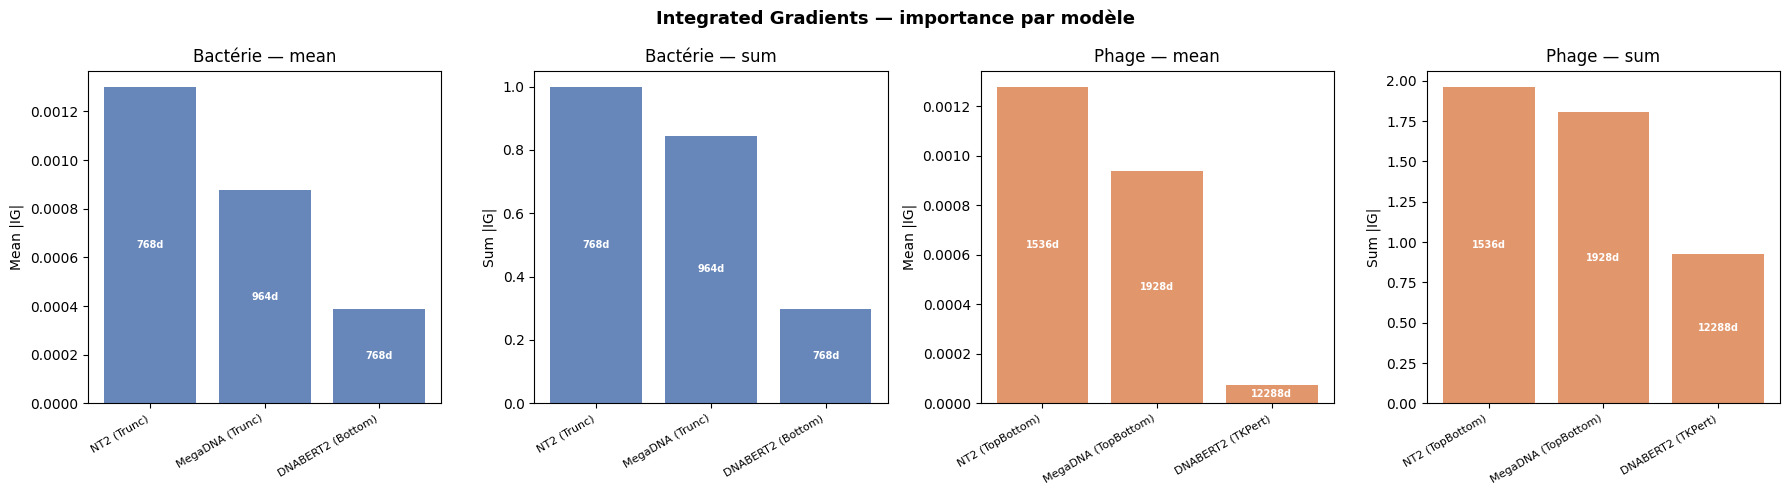

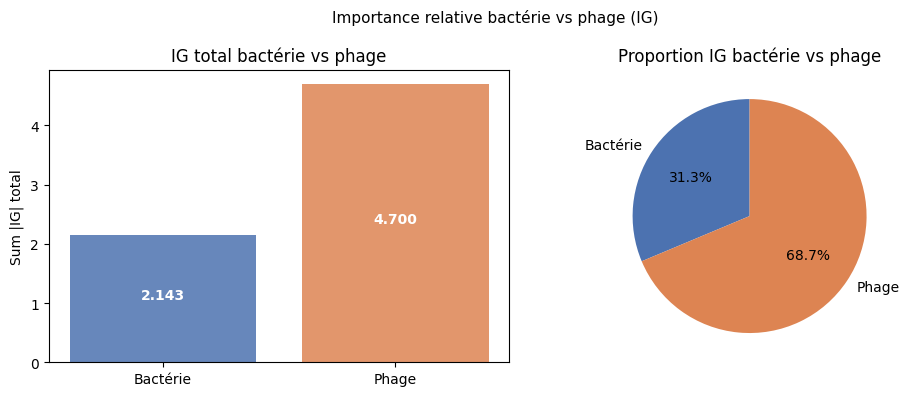

Bactérie : 2.143 (31.3%)
Phage    : 4.700 (68.7%)


In [61]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.subplots_adjust(bottom=0.25)

for ax, info_dict, attr, side, color, ylabel in [
    (axes[0], bact_info,  'mean', 'Bactérie', '#4C72B0', 'Mean |IG|'),
    (axes[1], bact_info,  'sum',  'Bactérie', '#4C72B0', 'Sum |IG|'),
    (axes[2], phage_info, 'mean', 'Phage',    '#DD8452', 'Mean |IG|'),
    (axes[3], phage_info, 'sum',  'Phage',    '#DD8452', 'Sum |IG|'),
]:
    labels = [info['display'] for info in info_dict.values()]
    vals   = [getattr(info['ig_importance'], attr)() for info in info_dict.values()]
    bars   = ax.bar(range(len(vals)), vals, color=color, alpha=0.85)
    ax.set_xticks(range(len(vals))); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'{side} — {attr}')
    ax.set_ylabel(ylabel)
    for bar, val, info in zip(bars, vals, info_dict.values()):
        ax.text(bar.get_x() + bar.get_width()/2, val * 0.5, str(info['size']) + 'd',
                ha='center', va='center', fontsize=7, color='white', fontweight='bold')

plt.suptitle('Integrated Gradients — importance par modèle', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Bactérie vs Phage : somme totale des IG ─────────────────────────────────
total_bact  = sum(info['ig_importance'].sum() for info in bact_info.values())
total_phage = sum(info['ig_importance'].sum() for info in phage_info.values())
total       = total_bact + total_phage

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart absolu
axes[0].bar(['Bactérie', 'Phage'], [total_bact, total_phage],
            color=['#4C72B0', '#DD8452'], alpha=0.85)
axes[0].set_ylabel('Sum |IG| total')
axes[0].set_title('IG total bactérie vs phage')
for i, v in enumerate([total_bact, total_phage]):
    axes[0].text(i, v * 0.5, f'{v:.3f}', ha='center', fontsize=10, color='white', fontweight='bold')

# Pie chart proportion
axes[1].pie([total_bact, total_phage], labels=['Bactérie', 'Phage'],
            colors=['#4C72B0', '#DD8452'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proportion IG bactérie vs phage')

plt.suptitle(f'Importance relative bactérie vs phage (IG)', fontsize=11)
plt.tight_layout(); plt.show()
print(f'Bactérie : {total_bact:.3f} ({100*total_bact/total:.1f}%)')
print(f'Phage    : {total_phage:.3f} ({100*total_phage/total:.1f}%)')


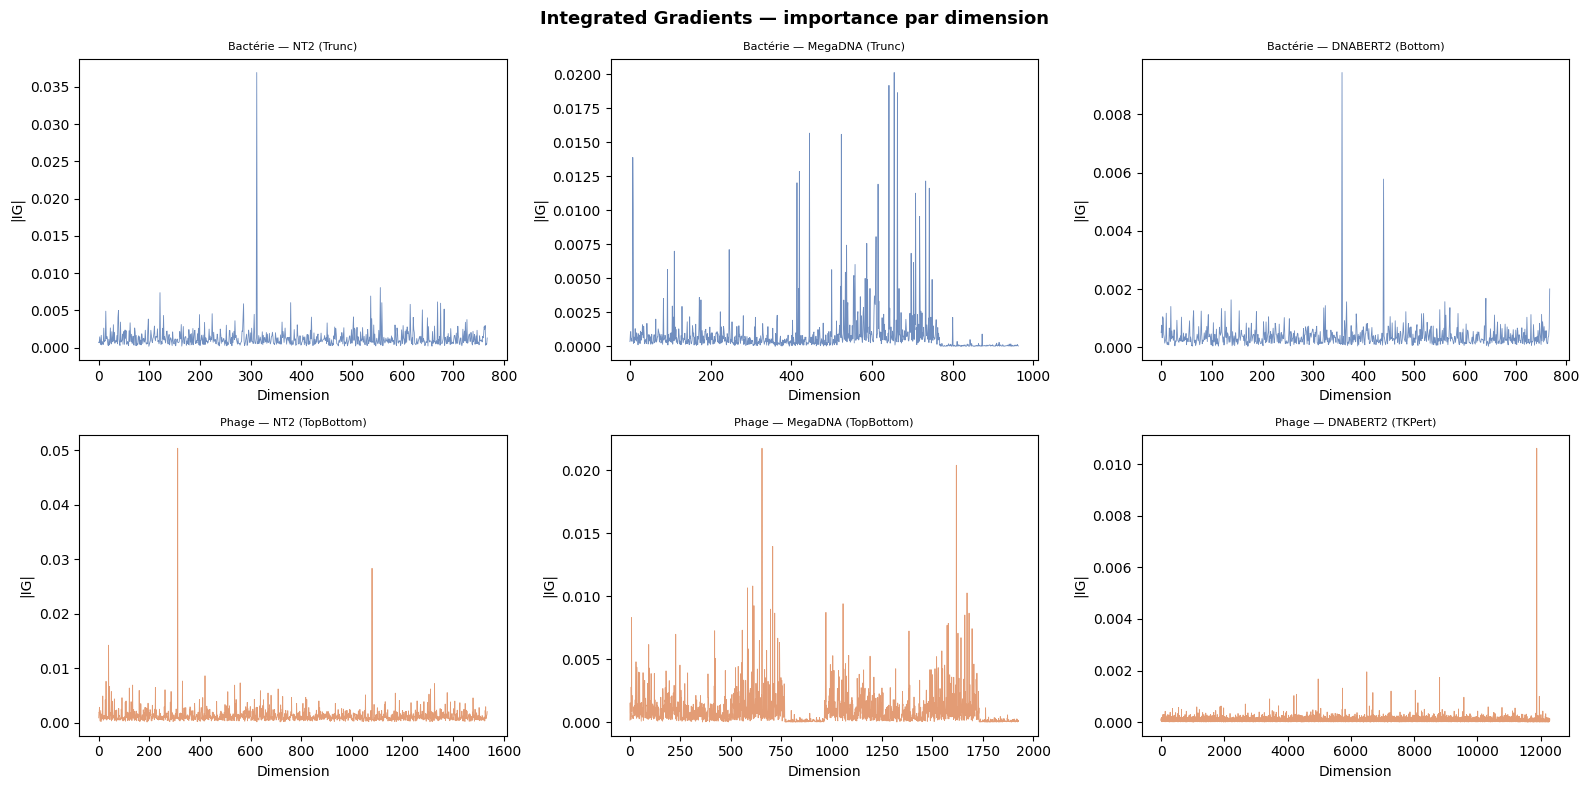

In [60]:
fig, axes = plt.subplots(2, len(bact_info), figsize=(16, 8))

for col, info in enumerate(bact_info.values()):
    axes[0][col].plot(info['ig_importance'], linewidth=0.6, alpha=0.8, color='#4C72B0')
    axes[0][col].set_title('Bactérie — ' + info['display'], fontsize=8)
    axes[0][col].set_xlabel('Dimension'); axes[0][col].set_ylabel('|IG|')

for col, info in enumerate(phage_info.values()):
    axes[1][col].plot(info['ig_importance'], linewidth=0.6, alpha=0.8, color='#DD8452')
    axes[1][col].set_title('Phage — ' + info['display'], fontsize=8)
    axes[1][col].set_xlabel('Dimension'); axes[1][col].set_ylabel('|IG|')

plt.suptitle('Integrated Gradients — importance par dimension', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### Ablation study — mise à zéro d'un modèle

On remplace les dimensions d'un modèle (NT2, MegaDNA, DNABERT2) par des zéros dans **tous les samples**,
puis on mesure la chute de F1 par rapport au modèle complet.

Si IG et gradient prédisent correctement l'importance, les modèles avec le plus grand sum d'importance
devraient causer la plus grande chute de F1 quand on les supprime.

In [30]:
import random


def swap_embeddings(dataset, infos):
    ds     = dataset.copy()
    n      = len(ds)
    others = [random.randint(0, n - 1) for _ in range(n)]
    for info in infos:
        col, sl = _col(info), info['slice']
        new = []
        for i, e in enumerate(ds[col]):
            e = e.clone(); e[sl] = dataset[col][others[i]][sl]; new.append(e)
        ds[col] = new
    return ds


def zero_embeddings(dataset, infos):
    ds = dataset.copy()
    for info in infos:
        col, sl = _col(info), info['slice']
        new = []
        for e in ds[col]:
            e = e.clone(); e[sl] = 0.0; new.append(e)
        ds[col] = new
    return ds


def random_embeddings(dataset, infos):
    ds = dataset.copy()
    for info in infos:
        col, sl = _col(info), info['slice']
        new = []
        for e in ds[col]:
            e = e.clone(); e[sl] = torch.randn(info['size']); new.append(e)
        ds[col] = new
    return ds


def get_mcc(ds):
    cm, _ = test_model(ds, model, batch_size=config.training_config.batch_size, device=device, silent=True)
    tn, fp, fn, tp = cm.ravel()
    denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)) ** 0.5
    return (tp*tn - fp*fn) / denom if denom > 0 else 0.0


def get_metrics(ds_orig, ds_perturbed):
    model.eval()
    delta_probs, delta_mses = [], []
    with torch.no_grad():
        for (_, ro), (_, rz) in zip(ds_orig.iterrows(), ds_perturbed.iterrows()):
            prob_o = float(ro['probability'])
            prob_z = torch.sigmoid(model(
                rz['bacterium_embedding'].float().to(device).unsqueeze(0),
                rz['phage_embedding'].float().to(device).unsqueeze(0)
            )[:, 1]).item()
            label  = float(ro['interaction_type'])
            delta_probs.append(abs(prob_o - prob_z))
            delta_mses.append((prob_o - label)**2 - (prob_z - label)**2)
    return np.mean(delta_probs), np.mean(delta_mses), get_mcc(ds_perturbed) - get_mcc(ds_orig)


def run_perturb(dataset, infos, perturb_fn, n_runs=3):
    results = [get_metrics(dataset, perturb_fn(dataset, infos)) for _ in range(n_runs)]
    return tuple(np.mean([r[k] for r in results]) for k in range(3))


In [31]:
baseline_mcc = get_mcc(dataset)
print(f'MCC baseline: {baseline_mcc:.4f}')

for info_dict in [bact_info, phage_info]:
    for name, info in info_dict.items():
        dp, dm, dmcc = run_perturb(dataset, [info], swap_embeddings, n_runs=5)
        info['ablation'] = {'dprob': dp, 'dmse': dm, 'dmcc': dmcc}
        print(f"{info['display']} ({info['side']}) — ΔMCC: {dmcc:+.4f}  - ΔMSE {dm:+.4f}")


MCC baseline: 0.5022
NT2 (Trunc) (bact) — ΔMCC: -0.1329  - ΔMSE -0.0237
MegaDNA (Trunc) (bact) — ΔMCC: -0.3652  - ΔMSE -0.1197
DNABERT2 (Bottom) (bact) — ΔMCC: +0.0047  - ΔMSE +0.0237
NT2 (TopBottom) (phage) — ΔMCC: -0.3797  - ΔMSE -0.1326
MegaDNA (TopBottom) (phage) — ΔMCC: -0.1603  - ΔMSE -0.0276
DNABERT2 (TKPert) (phage) — ΔMCC: -0.0278  - ΔMSE +0.0130


In [32]:
# Ablation séparée top / bottom pour les modèles TopBottomTruncateStrategy
for name, info in topbottom_info.items():

    dp, dm, dmcc = run_perturb(dataset, [info], swap_embeddings, n_runs=5)
    info['ablation'] = {'dprob': dp, 'dmse': dm, 'dmcc': dmcc}
    print(f"{info['display']} ({info['side']}) — ΔMCC: {dmcc:+.4f}  - ΔMSE {dm:+.4f}")


NT2 (Top splited) (phage) — ΔMCC: -0.3297  - ΔMSE -0.0984
NT2 (Bottom splited) (phage) — ΔMCC: -0.0361  - ΔMSE +0.0081
MegaDNA (Top splited) (phage) — ΔMCC: -0.0362  - ΔMSE +0.0076
MegaDNA (Bottom splited) (phage) — ΔMCC: -0.0492  - ΔMSE +0.0048


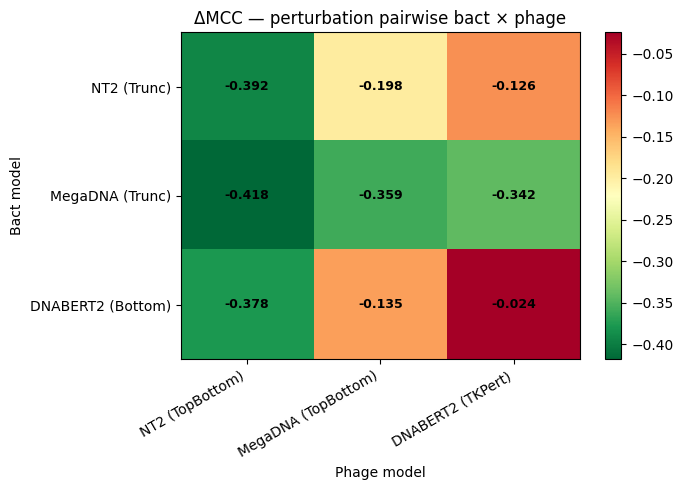

In [33]:
matrix_dmcc = np.zeros((len(bact_info), len(phage_info)))

for i, b_info in enumerate(bact_info.values()):
    for j, p_info in enumerate(phage_info.values()):
        results = [get_metrics(dataset, swap_embeddings(dataset, [b_info, p_info])) for _ in range(5)]
        matrix_dmcc[i, j] = np.mean([r[2] for r in results])

xlabels = [info['display'] for info in phage_info.values()]
ylabels = [info['display'] for info in bact_info.values()]

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(matrix_dmcc, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(xlabels))); ax.set_xticklabels(xlabels, rotation=30, ha='right')
ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels)
ax.set_xlabel('Phage model'); ax.set_ylabel('Bact model')
ax.set_title('ΔMCC — perturbation pairwise bact × phage')
plt.colorbar(im, ax=ax)
for i in range(len(ylabels)):
    for j in range(len(xlabels)):
        ax.text(j, i, f'{matrix_dmcc[i,j]:+.3f}', ha='center', va='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()


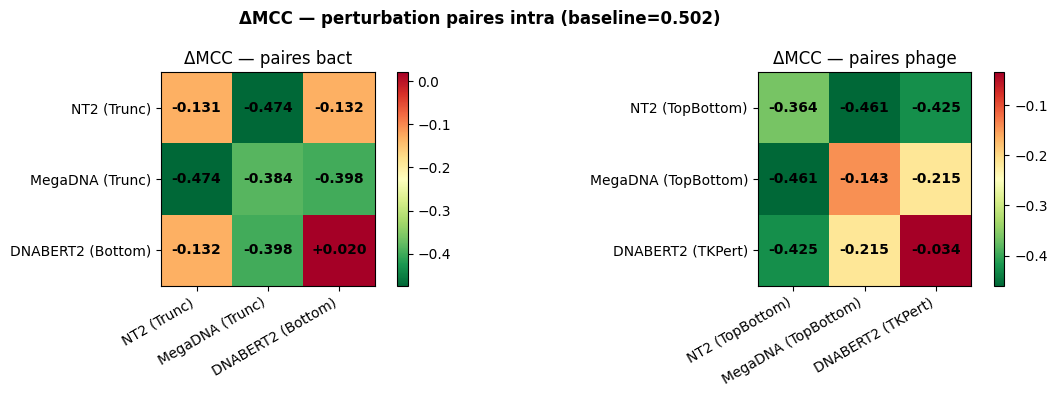

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, info_dict in [(axes[0], bact_info), (axes[1], phage_info)]:
    infos  = list(info_dict.values())
    n      = len(infos)
    matrix = np.full((n, n), np.nan)

    for i in range(n):
        for j in range(i, n):
            to_perturb = [infos[i]] if i == j else [infos[i], infos[j]]
            results    = [get_mcc(swap_embeddings(dataset, to_perturb)) for _ in range(3)]
            matrix[i, j] = matrix[j, i] = np.mean(results) - baseline_mcc

    labels = [info['display'] for info in infos]
    side   = infos[0]['side']
    im = ax.imshow(matrix, cmap='RdYlGn_r', vmin=matrix.min(), vmax=matrix.max())
    ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_yticks(range(n)); ax.set_yticklabels(labels)
    ax.set_title(f'ΔMCC — paires {side}')
    plt.colorbar(im, ax=ax)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{matrix[i,j]:+.3f}', ha='center', va='center', fontsize=10, fontweight='bold')

plt.suptitle(f'ΔMCC — perturbation paires intra (baseline={baseline_mcc:.3f})', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


Modèles entiers
  6 modèles → 41 coalitions
    k=1 done (6 coalitions)
    k=2 done (15 coalitions)
    k=3 done (20 coalitions)
TopBottom
  4 modèles → 14 coalitions
    k=1 done (4 coalitions)
    k=2 done (6 coalitions)
    k=3 done (4 coalitions)


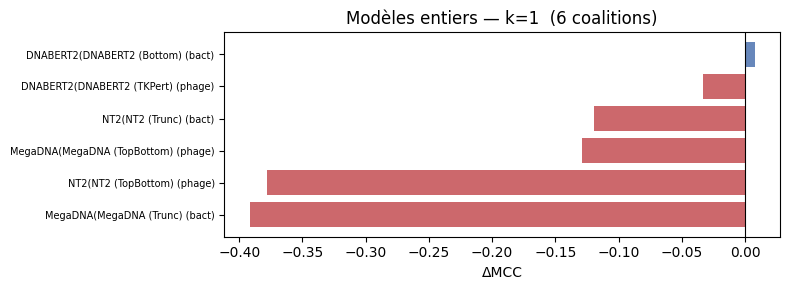

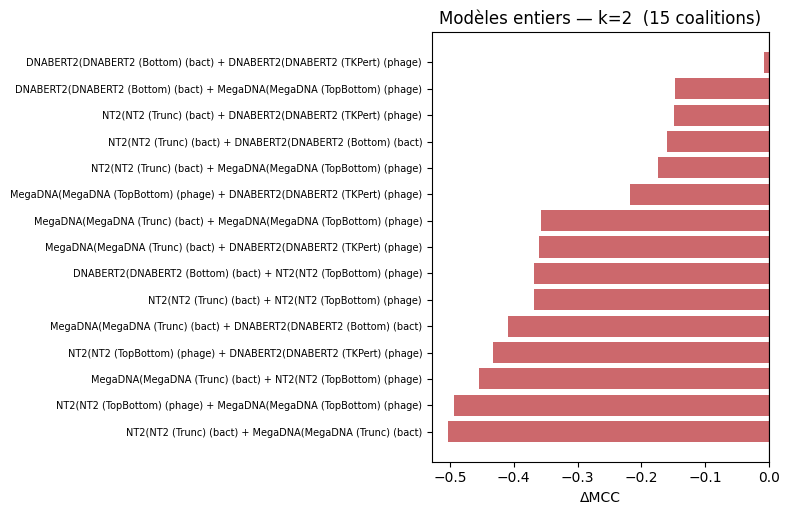

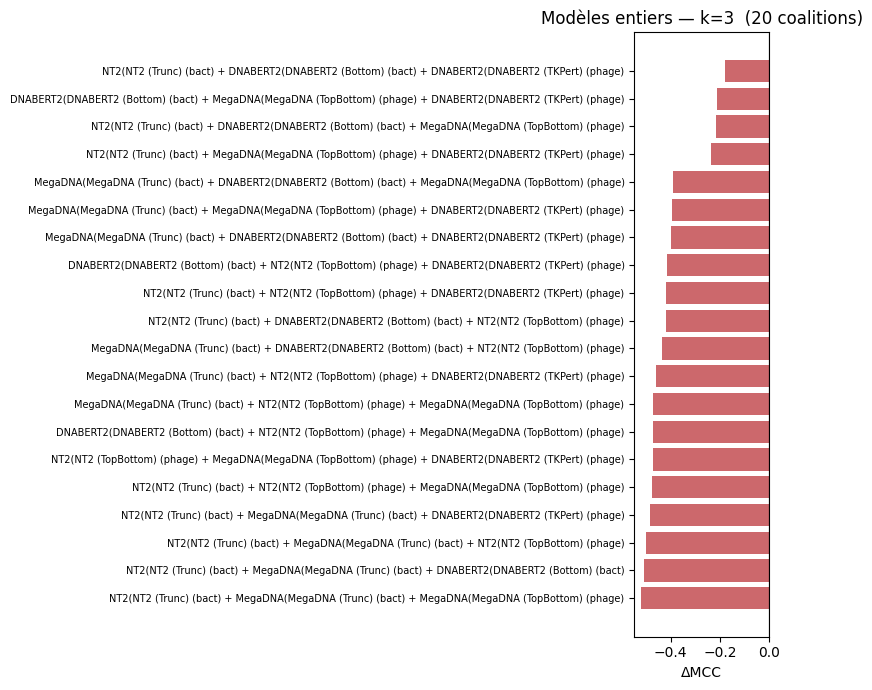

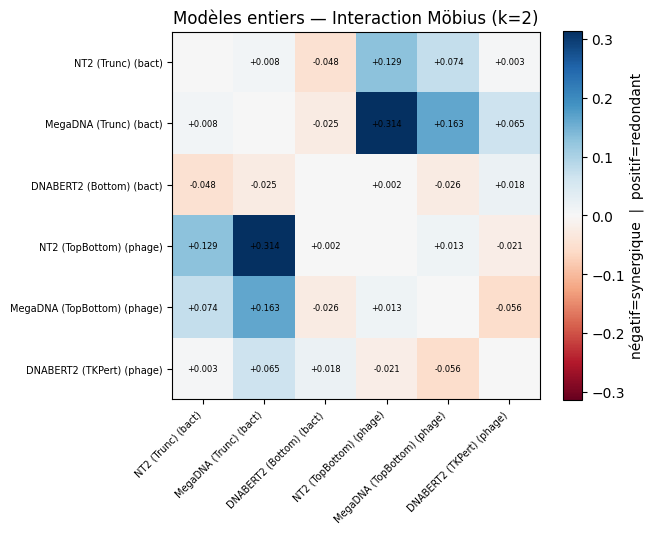

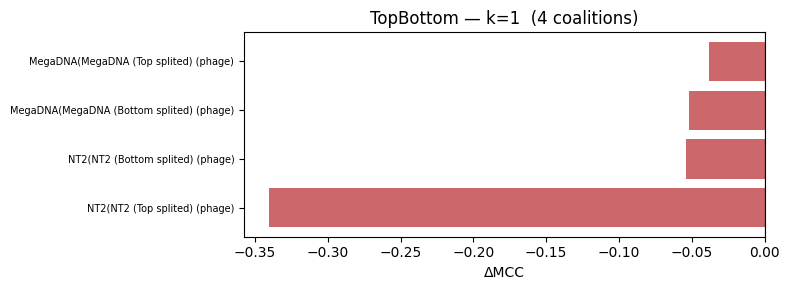

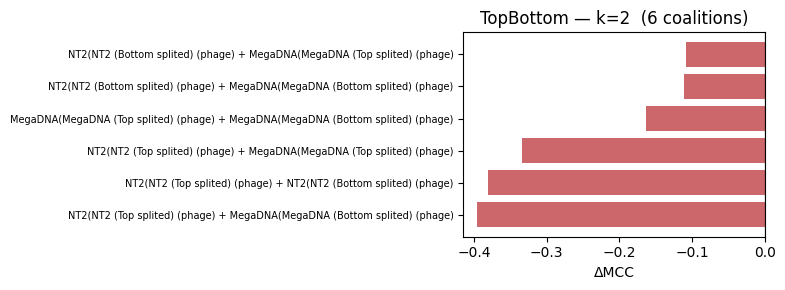

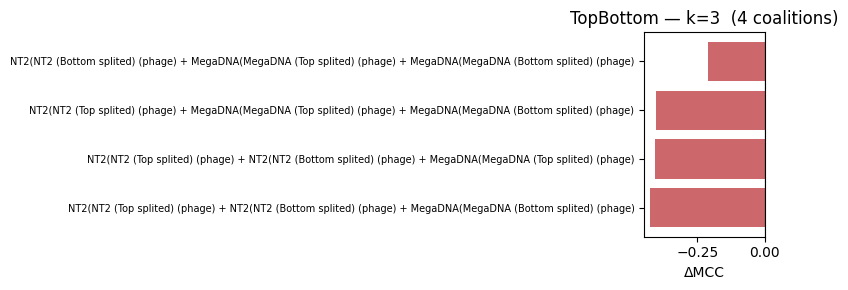

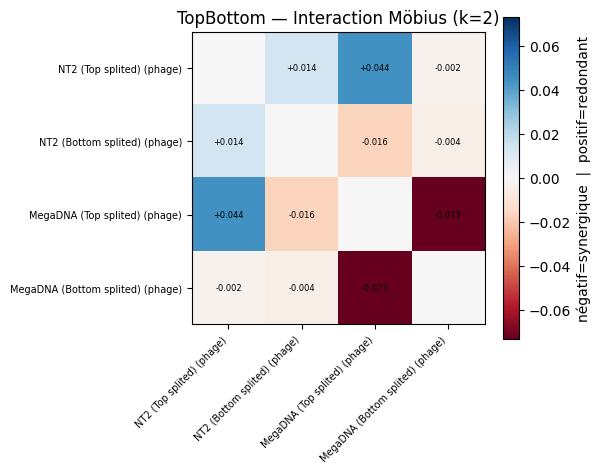

In [62]:
from itertools import combinations

MAX_K  = 3
N_RUNS = 3

# ─── Deux configurations à comparer ──────────────────────────────────────────
all_infos = list(bact_info.values()) + list(phage_info.values())



all_infos_split = []
for name, info in {**bact_info, **phage_info}.items():
    if 'TopBottom' in info['display']:
        all_infos_split += [topbottom_info[name + '_top'], topbottom_info[name + '_bottom']]
    else:
        all_infos_split.append(info)

configs = [
    ('Modèles entiers',          all_infos),
    ('TopBottom', list(topbottom_info.values())),
]

# ─── Calcul des coalitions jusqu'à MAX_K ─────────────────────────────────────
def compute_coalitions(all_infos):
    N     = len(all_infos)
    total = sum(len(list(combinations(range(N), k))) for k in range(1, MAX_K + 1))
    print(f'  {N} modèles → {total} coalitions')
    v = {frozenset(): baseline_mcc}
    for size in range(1, MAX_K + 1):
        for S in combinations(range(N), size):
            key    = frozenset(S)
            infos  = [all_infos[i] for i in S]
            v[key] = np.mean([get_mcc(swap_embeddings(dataset, infos)) for _ in range(N_RUNS)])
        print(f'    k={size} done ({len(list(combinations(range(N), size)))} coalitions)')
    return v

results = {}
for title, all_infos in configs:
    print(title)
    results[title] = (all_infos, compute_coalitions(all_infos))

# ─── Affichage ────────────────────────────────────────────────────────────────
def plot_coalition(all_infos, v, title):
    N     = len(all_infos)
    short = [info['display'] + ' (' + info['side'] + ')' for info in all_infos]

    def delta(S):
        return v[frozenset(S)] - baseline_mcc

    def mobius2(i, j):
        return v[frozenset([i,j])] - v[frozenset([i])] - v[frozenset([j])] + baseline_mcc

    # ── k=1 à MAX_K : bar chart par taille ──────────────────────────────────
    for size in range(1, MAX_K + 1):
        all_S = list(combinations(range(N), size))
        data  = sorted([(S, delta(S)) for S in all_S], key=lambda x: x[1])
        lbls  = [' + '.join(short[i].split(' (')[0] + '(' + short[i] for i in S) for S, _ in data]
        vals  = [d for _, d in data]

        fig, ax = plt.subplots(figsize=(8, max(3, len(data) * 0.35)))
        ax.barh(range(len(data)), vals,
                color=['#c44e52' if d < 0 else '#4c72b0' for d in vals], alpha=0.85)
        ax.set_yticks(range(len(data)))
        ax.set_yticklabels(lbls, fontsize=7)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('ΔMCC')
        ax.set_title(f'{title} — k={size}  ({len(data)} coalitions)')
        plt.tight_layout(); plt.show()

    # ── k=2 : heatmap Möbius en plus ────────────────────────────────────────
    if MAX_K >= 2:
        I2 = np.zeros((N, N))
        for i, j in combinations(range(N), 2):
            I2[i,j] = I2[j,i] = mobius2(i, j)

        fig, ax = plt.subplots(figsize=(max(6, N * 1.1), max(5, N * 0.9)))
        vmax = np.abs(I2).max() or 1
        im   = ax.imshow(I2, cmap='RdBu', vmin=-vmax, vmax=vmax)
        ax.set_xticks(range(N)); ax.set_xticklabels(short, rotation=45, ha='right', fontsize=7)
        ax.set_yticks(range(N)); ax.set_yticklabels(short, fontsize=7)
        for i in range(N):
            for j in range(N):
                if i != j:
                    ax.text(j, i, f'{I2[i,j]:+.3f}', ha='center', va='center', fontsize=6)
        plt.colorbar(im, ax=ax, label='négatif=synergique  |  positif=redondant')
        ax.set_title(f'{title} — Interaction Möbius (k=2)')
        plt.tight_layout(); plt.show()

for title, (all_infos, v) in results.items():
    plot_coalition(all_infos, v, title)


In [ ]:
to_remove  = [info for info in bact_info.values()  if 'DNABERT2' in info['display']]
to_remove += [info for info in phage_info.values() if 'DNABERT2' in info['display']]
#to_remove += [_sub_info(info, 'bottom') for info in phage_info.values()  if 'NT2'     in info['display'] and 'TopBottom' in info['display']]
#to_remove += [_sub_info(info, 'top')    for info in phage_info.values()  if 'MegaDNA' in info['display'] and 'TopBottom' in info['display']]

print('Supprime:', [(info['slice'], info['side']) for info in to_remove])

mcc_reduced = np.mean([get_mcc(swap_embeddings(dataset, to_remove)) for _ in range(15)])
print(f'MCC baseline      : {baseline_mcc:.4f}')
print(f'MCC modèle réduit : {mcc_reduced:.4f}')
print(f'ΔMCC              : {mcc_reduced - baseline_mcc:+.4f}')


Supprime: [(slice(1732, 2500, None), 'bact'), (slice(3464, 15752, None), 'phage')]
MCC baseline      : 0.5022
MCC modèle réduit : 0.4800
ΔMCC              : -0.0222


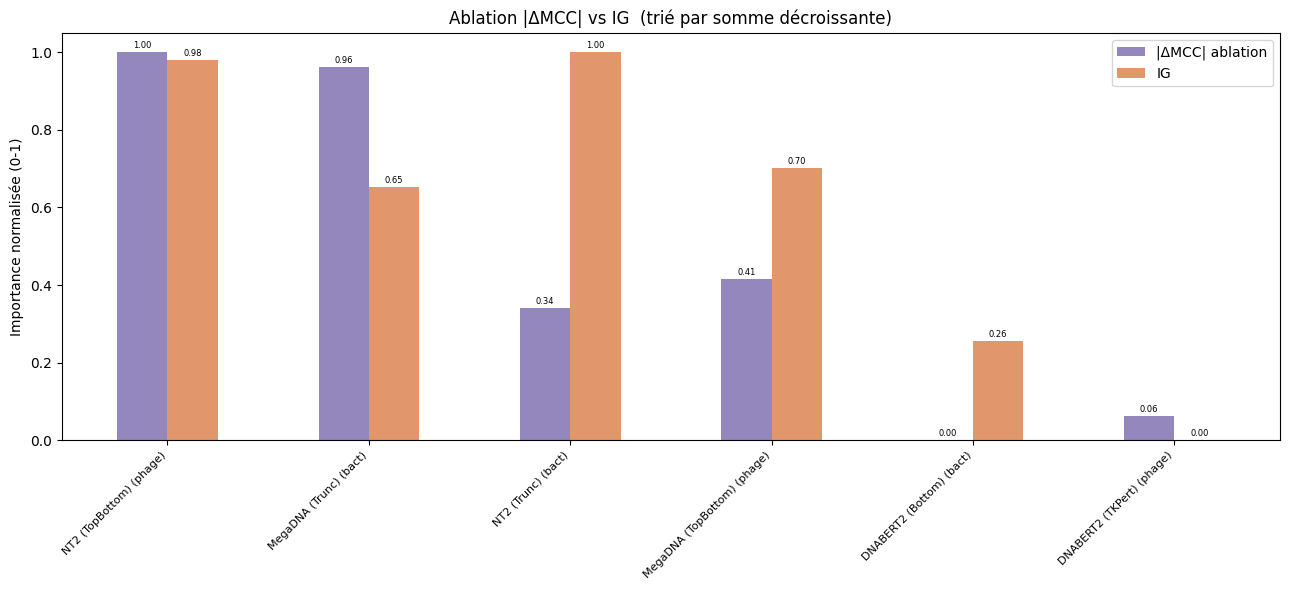

Classement par somme normalisée :
  NT2 (TopBottom) (phage)                   score=1.981
  MegaDNA (Trunc) (bact)                    score=1.614
  NT2 (Trunc) (bact)                        score=1.342
  MegaDNA (TopBottom) (phage)               score=1.118
  DNABERT2 (Bottom) (bact)                  score=0.255
  DNABERT2 (TKPert) (phage)                 score=0.062


In [51]:
all_entries = list(bact_info.values()) + list(phage_info.values())

def normalize(arr):
    arr = np.array(arr, dtype=float)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-10)

labels    = [f"{info['display']} ({info['side']})" for info in all_entries]
dmcc_vals = [abs(info['ablation']['dmcc'])           for info in all_entries]
ig_vals   = [info['ig_importance'].mean()            for info in all_entries]

norm_dmcc = normalize(dmcc_vals)
norm_ig   = normalize(ig_vals)
score     = norm_dmcc + norm_ig

# Trier par score décroissant
order = np.argsort(score)[::-1]
labels_s    = [labels[i]    for i in order]
norm_dmcc_s = [norm_dmcc[i] for i in order]
norm_ig_s   = [norm_ig[i]   for i in order]
score_s     = [score[i]     for i in order]

x, width = np.arange(len(all_entries)), 0.25
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width/2, norm_dmcc_s, width, label='|ΔMCC| ablation', color='#8172B2', alpha=0.85)
ax.bar(x + width/2, norm_ig_s,   width, label='IG',              color='#DD8452', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels_s, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Importance normalisée (0-1)')
ax.set_title('Ablation |ΔMCC| vs IG  (trié par somme décroissante)')
ax.legend()
for i, (va, vi) in enumerate(zip(norm_dmcc_s, norm_ig_s)):
    ax.text(i - width/2, va + 0.01, f'{va:.2f}', ha='center', fontsize=6)
    ax.text(i + width/2, vi + 0.01, f'{vi:.2f}', ha='center', fontsize=6)
plt.tight_layout(); plt.show()

print('Classement par somme normalisée :')
for lbl, s in zip(labels_s, score_s):
    print(f'  {lbl:40s}  score={s:.3f}')
